In [1]:
import numpy as np
import matplotlib.pyplot as plt

## What Does Central Limit Theorem Really Means

According to Wikipedia, the central limit theorem (CLT) states that, under appropriate conditions, the distribution of a normalized version of the sample mean converges to a standard normal distribution. 

### Lets think about what that means:

Firstly imagine that you are rolling a dice (1 - 6). If you count the probably of how many times you got any number, it should be 1/6, assuming a dice is fair. This random variable is an example of uniform distribution. But, central limit theorem states that if we take a bunch of independent (outcomes that are not affected by other outcomes) and identically distributed (the outcomes (Random Variables) have the same distribution), it will converge to a normal distributin with sufficient amount of sample means. Lets look into it:

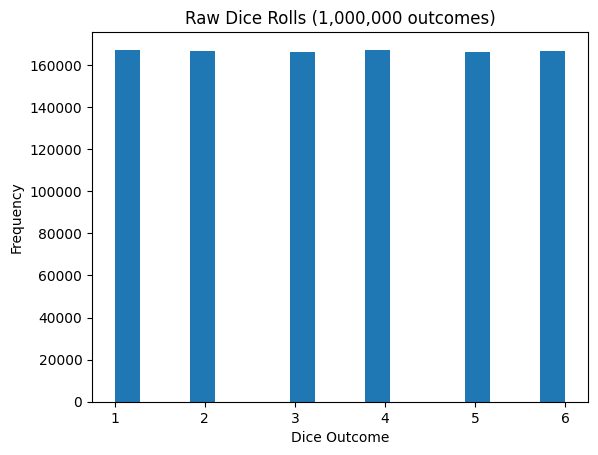

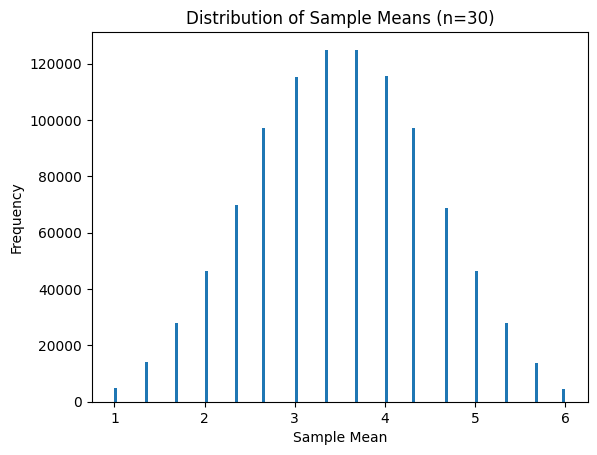

In [29]:
plt.hist(diceroll_outcomes_1000000, bins=18)
plt.xlabel("Dice Outcome")
plt.ylabel("Frequency")
plt.title("Raw Dice Rolls (1,000,000 outcomes)")
plt.show()

plt.hist(diceroll_means_1000000, bins='auto')
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (n=30)")
plt.show()


(array([  4716.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,  14017.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,  27884.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  46516.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,  69750.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,  97267.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0., 115415.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
        124898.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 124994.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0., 115757.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
      

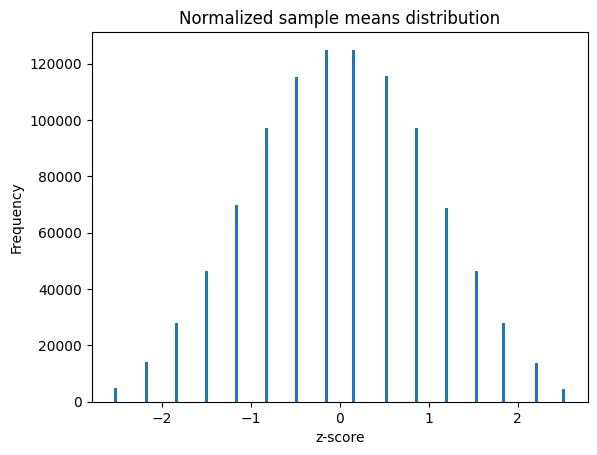

In [24]:
mean = np.mean(diceroll_means_1000000)
std = np.std(diceroll_means_1000000)

normalized = (diceroll_means_1000000 - mean) / std

plt.xlabel("z-score")
plt.ylabel("Frequency")
plt.title("Normalized sample means distribution")

plt.hist(normalized, bins='auto')

## Does this also work for non-uniform distributions?

The dice gave us a uniform distribution to start with — every outcome equally likely. But the CLT is far stronger than that: it works for almost any distribution, as long as the mean and variance are finite. Let's verify that by trying a few that look nothing like a bell curve to begin with — a one-sided exponential, a binary coin flip, a discrete count, and a heavy right-tailed lognormal. In each case we'll plot the raw distribution and then the distribution of sample means at n=30, exactly the way we did for the dice.

### Exponential — wait times

The exponential distribution models the time between independent events that happen at a constant average rate: the time until the next bus, the next earthquake, the next customer walking in. Its shape is heavily right-skewed — short waits are common, long waits are rare but possible. Nothing about that shape looks normal, and yet…

In [ ]:
exp_outcomes = np.random.exponential(scale=2.0, size=1_000_000)
exp_means = np.random.exponential(scale=2.0, size=(100_000, 30)).mean(axis=1)

plt.hist(exp_outcomes, bins=80)
plt.xlabel("Wait time")
plt.ylabel("Frequency")
plt.title("Raw Exponential samples (1,000,000 outcomes)")
plt.show()

plt.hist(exp_means, bins='auto')
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (n=30)")
plt.show()

### Bernoulli — coin flips and polls

A Bernoulli random variable takes only two values: 1 (success) with probability p, or 0 (failure) with probability 1 − p. Think of a single coin flip, a yes/no poll answer, or a click / no-click event. The raw histogram is just two bars — and yet the average of many of them still lines up into a bell.

In [ ]:
bern_outcomes = np.random.binomial(n=1, p=0.3, size=1_000_000)
bern_means = np.random.binomial(n=1, p=0.3, size=(100_000, 30)).mean(axis=1)

plt.hist(bern_outcomes, bins=[-0.5, 0.5, 1.5])
plt.xlabel("Outcome (0 or 1)")
plt.ylabel("Frequency")
plt.title("Raw Bernoulli samples (p=0.3, 1,000,000 outcomes)")
plt.show()

plt.hist(bern_means, bins='auto')
plt.xlabel("Sample Mean (estimated p)")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (n=30)")
plt.show()

### Poisson — counts of rare events

A Poisson random variable counts how many times something happens in a fixed window when the events are independent and occur at a constant average rate: emails per hour, goals per match, defects per batch. It is discrete and (for small λ) right-skewed.

In [ ]:
poisson_outcomes = np.random.poisson(lam=3.0, size=1_000_000)
poisson_means = np.random.poisson(lam=3.0, size=(100_000, 30)).mean(axis=1)

plt.hist(poisson_outcomes, bins=range(0, 15))
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Raw Poisson samples (λ=3, 1,000,000 outcomes)")
plt.show()

plt.hist(poisson_means, bins='auto')
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (n=30)")
plt.show()

### Lognormal — heavy right tails

The lognormal distribution shows up whenever a quantity is the product of many small independent effects: incomes, file sizes, stock prices, time-to-failure of components. It has a heavy right tail — most values are modest, but a few are enormous. This makes the convergence to a bell noticeably slower than for the others, but with n=30 you can already see it happening.

In [ ]:
lognorm_outcomes = np.random.lognormal(mean=0.0, sigma=1.0, size=1_000_000)
lognorm_means = np.random.lognormal(mean=0.0, sigma=1.0, size=(100_000, 30)).mean(axis=1)

plt.hist(lognorm_outcomes, bins=200, range=(0, 15))
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Raw Lognormal samples (1,000,000 outcomes)")
plt.show()

plt.hist(lognorm_means, bins='auto')
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (n=30)")
plt.show()

## Why does this matter? Real-world payoff

So far we have seen *that* the sample mean lands near the true mean and forms a bell as the sample size grows. But the result that actually drives real decisions is the *width* of that bell: the std of the sample mean is $\sigma / \sqrt{n}$. That single formula is why a 1,000-person poll reports a ±3% margin, why averaging four noisy sensors halves the noise, and why "more data" pays off — but with diminishing returns at a rate of $\sqrt{n}$, not $n$. Let's see it in two settings.

### Election polling — where the ±3% comes from

A poll asks $n$ people a yes/no question. Each person is a Bernoulli draw with some true probability $p$ of saying yes. A single Bernoulli has std $\sqrt{p(1-p)}$, which is at most $0.5$ (at $p=0.5$). So the std of the *poll average* is at most $0.5 / \sqrt{n}$. With $n = 1000$, that is about $0.0158$. The 95% margin of error is $1.96 \times$ that — about $3.1\%$. That is literally where the famous ±3% comes from.

In [36]:
true_p = 0.52         # the real preference in the population
n_voters = 1000

poll = np.random.binomial(n=1, p=true_p, size=n_voters)
estimate = poll.mean()

# Standard error of the proportion (using the estimate as a stand-in for p)
se = np.sqrt(estimate * (1 - estimate) / n_voters)
moe = 1.96 * se

print(f"True p:        {true_p}")
print(f"Poll estimate: {estimate:.3f}")
print(f"Std error:     {se:.4f}")
print(f"95% margin:    ±{moe:.4f}  ({100*moe:.2f}%)")
print(f"95% CI:        ({estimate - moe:.3f}, {estimate + moe:.3f})")

True p:        0.52
Poll estimate: 0.516
Std error:     0.0158
95% margin:    ±0.0310  (3.10%)
95% CI:        (0.485, 0.547)


n=  100  estimate=0.570  ±9.70%
n=  500  estimate=0.520  ±4.38%
n= 1000  estimate=0.528  ±3.09%
n= 5000  estimate=0.527  ±1.38%
n=10000  estimate=0.522  ±0.98%


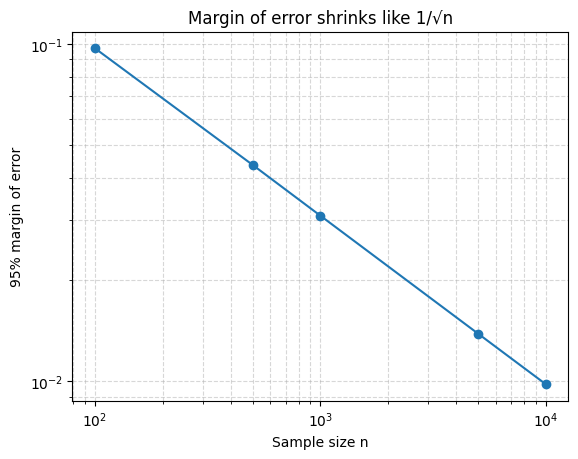

In [37]:
# How does the margin shrink as we poll more people?
sample_sizes = [100, 500, 1000, 5000, 10000]
moes = []

for n in sample_sizes:
    poll = np.random.binomial(n=1, p=true_p, size=n)
    p_hat = poll.mean()
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    moe = 1.96 * se
    moes.append(moe)
    print(f"n={n:5d}  estimate={p_hat:.3f}  ±{100*moe:.2f}%")

plt.loglog(sample_sizes, moes, marker='o')
plt.xlabel("Sample size n")
plt.ylabel("95% margin of error")
plt.title("Margin of error shrinks like 1/√n")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### Averaging noisy measurements

Same math, different setting. Suppose you are trying to measure a true value — a temperature, a voltage, a length — but every reading is noisy: the reading equals the true value plus some Gaussian noise of std $\sigma$. If you average $k$ independent readings, the std of that average is $\sigma / \sqrt{k}$. So with 4 readings the noise halves; with 16 it quarters; with 100 it shrinks by 10×. This is *the* reason scientific measurements are always reported as averages.

k=   1   empirical std=0.9927   theoretical σ/√k=1.0000
k=   4   empirical std=0.4953   theoretical σ/√k=0.5000
k=  16   empirical std=0.2478   theoretical σ/√k=0.2500
k=  64   empirical std=0.1249   theoretical σ/√k=0.1250
k= 256   empirical std=0.0624   theoretical σ/√k=0.0625


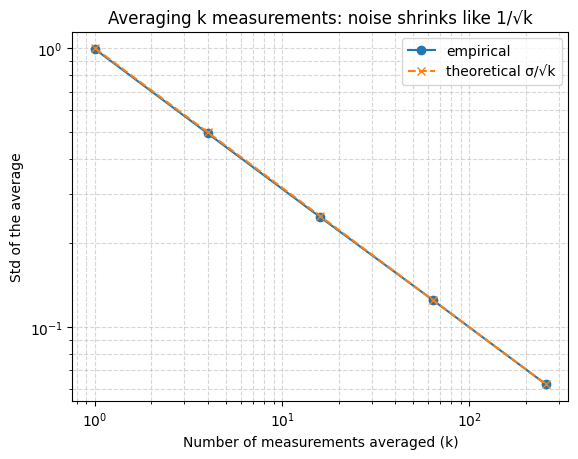

In [38]:
true_value = 10.0
noise_sigma = 1.0
num_trials = 10_000

k_values = [1, 4, 16, 64, 256]
empirical_stds = []
theoretical_stds = []

for k in k_values:
    # num_trials separate experiments, each averaging k noisy readings
    readings = np.random.normal(loc=true_value, scale=noise_sigma, size=(num_trials, k))
    averages = readings.mean(axis=1)
    empirical_stds.append(averages.std())
    theoretical_stds.append(noise_sigma / np.sqrt(k))
    print(f"k={k:4d}   empirical std={averages.std():.4f}   theoretical σ/√k={noise_sigma / np.sqrt(k):.4f}")

plt.plot(k_values, empirical_stds, marker='o', label="empirical")
plt.plot(k_values, theoretical_stds, marker='x', linestyle='--', label="theoretical σ/√k")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of measurements averaged (k)")
plt.ylabel("Std of the average")
plt.title("Averaging k measurements: noise shrinks like 1/√k")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Confidence intervals — putting a number on uncertainty

Everything above is built around a single estimate — the poll number, the averaged measurement. A *confidence interval* makes the uncertainty around that estimate explicit. The 95% confidence interval is:

$$ \bar{X} \pm 1.96 \cdot \frac{\sigma}{\sqrt{n}} $$

Where does the **1.96** come from? It is the z-score that brackets the middle 95% of a standard normal distribution — i.e. for a standard normal $Z$, $P(-1.96 < Z < 1.96) \approx 0.95$. The CLT tells us the sample mean is approximately normal with std $\sigma/\sqrt{n}$, so we just scale that bracket back to the sample-mean scale.

**Important interpretation.** A 95% CI does *not* mean "there is a 95% chance the true mean is in *this* interval." Once you've computed an interval, the true $\mu$ is either inside or outside it — there's no probability left. What 95% means is: **if we repeated the whole experiment many times, 95% of the intervals we would build would contain $\mu$.** It is a statement about the *procedure*, not about any single interval.

(In practice we usually don't know $\sigma$ either, so we estimate it from the sample and use the Student-$t$ distribution instead of $\pm 1.96$. For large $n$ the difference is tiny, so the formula above is a fine approximation.)

In [39]:
true_mu = 2.0       # true mean of an Exponential(scale=2)
sigma = 2.0         # true std of an Exponential(scale=2) is also the scale
sample_size = 30

sample = np.random.exponential(scale=2.0, size=sample_size)
x_bar = sample.mean()
se = sigma / np.sqrt(sample_size)
lo, hi = x_bar - 1.96 * se, x_bar + 1.96 * se

print(f"Sample mean: {x_bar:.3f}")
print(f"Std error:   {se:.3f}")
print(f"95% CI:      ({lo:.3f}, {hi:.3f})")
print(f"True μ={true_mu} is {'inside' if lo <= true_mu <= hi else 'OUTSIDE'} this CI")

Sample mean: 1.585
Std error:   0.365
95% CI:      (0.870, 2.301)
True μ=2.0 is inside this CI


In [40]:
# Does the procedure really catch μ 95% of the time?
num_trials = 10_000

samples = np.random.exponential(scale=2.0, size=(num_trials, sample_size))
x_bars = samples.mean(axis=1)
los = x_bars - 1.96 * (sigma / np.sqrt(sample_size))
his = x_bars + 1.96 * (sigma / np.sqrt(sample_size))
hits = int(((los <= true_mu) & (true_mu <= his)).sum())

print(f"Out of {num_trials} CIs, {hits} contained μ={true_mu}")
print(f"Coverage: {hits / num_trials:.3f}  (target: 0.95)")

Out of 10000 CIs, 9501 contained μ=2.0
Coverage: 0.950  (target: 0.95)


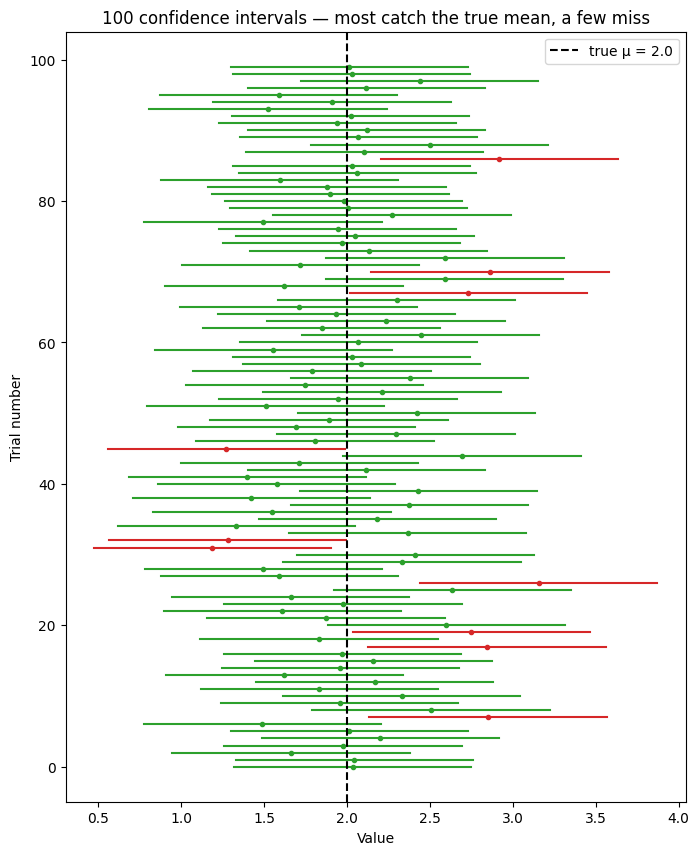

In [41]:
# Visualize the first 100 CIs. Each horizontal bar is one interval;
# green = contains true μ, red = misses.
num_to_plot = 100

plt.figure(figsize=(8, 10))
for i in range(num_to_plot):
    sample = np.random.exponential(scale=2.0, size=sample_size)
    x_bar = sample.mean()
    lo = x_bar - 1.96 * (sigma / np.sqrt(sample_size))
    hi = x_bar + 1.96 * (sigma / np.sqrt(sample_size))
    color = "tab:green" if lo <= true_mu <= hi else "tab:red"
    plt.plot([lo, hi], [i, i], color=color, lw=1.5)
    plt.plot(x_bar, i, "o", color=color, markersize=3)

plt.axvline(true_mu, color="black", linestyle="--", label=f"true μ = {true_mu}")
plt.xlabel("Value")
plt.ylabel("Trial number")
plt.title("100 confidence intervals — most catch the true mean, a few miss")
plt.legend()
plt.show()